# Data Workflow Project: Titanic Dataset Analysis

**Author:** Sambasiva Andaluri

**Dataset:** Titanic - Machine Learning from Disaster ([Kaggle Link](https://www.kaggle.com/c/titanic))

**Project Description:** This project demonstrates a complete, reproducible data workflow using the Titanic passenger dataset. The workflow includes data ingestion, cleaning, exploratory analysis, and visualization to understand factors that influenced passenger survival rates during the Titanic disaster.

---
## 1. Setup: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

---
## 2. Data Ingestion

In [2]:
# Load the Titanic dataset
df = pd.read_csv('titanic.csv')

# Display first few rows
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Shape: 891 rows, 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


---
## 3. Data Cleaning

The dataset has missing values in the `Age`, `Cabin`, and `Embarked` columns. We will create cleaning functions to handle these issues.

In [4]:
def fill_missing_age(dataframe, group_cols=['Pclass', 'Sex']):
    """
    Fill missing Age values using the median age grouped by passenger class and sex.
    
    This approach preserves the relationship between age and other demographic factors
    rather than using a single global median, which would ignore important correlations.
    
    Parameters:
    -----------
    dataframe : pandas.DataFrame
        The input dataframe containing an 'Age' column
    group_cols : list
        Columns to group by when calculating median age
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with missing Age values filled
    """
    df_copy = dataframe.copy()
    
    # Calculate median age for each group
    median_ages = df_copy.groupby(group_cols)['Age'].transform('median')
    
    # Fill missing ages with group median
    df_copy['Age'] = df_copy['Age'].fillna(median_ages)
    
    # If any still missing (edge case), fill with overall median
    df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].median())
    
    print(f"Filled {dataframe['Age'].isna().sum()} missing Age values")
    return df_copy

In [5]:
def clean_categorical_columns(dataframe):
    """
    Clean categorical columns by filling missing values and standardizing formats.
    
    - Fills missing 'Embarked' values with the mode (most common port)
    - Creates a 'HasCabin' binary feature from the Cabin column
    - Drops the original Cabin column (too many missing values to impute meaningfully)
    
    Parameters:
    -----------
    dataframe : pandas.DataFrame
        The input dataframe
    
    Returns:
    --------
    pandas.DataFrame
        Cleaned dataframe with processed categorical columns
    """
    df_copy = dataframe.copy()
    
    # Fill missing Embarked with mode
    embarked_mode = df_copy['Embarked'].mode()[0]
    missing_embarked = df_copy['Embarked'].isna().sum()
    df_copy['Embarked'] = df_copy['Embarked'].fillna(embarked_mode)
    print(f"Filled {missing_embarked} missing Embarked values with '{embarked_mode}'")
    
    # Create HasCabin feature (1 if cabin is known, 0 otherwise)
    df_copy['HasCabin'] = df_copy['Cabin'].notna().astype(int)
    print(f"Created 'HasCabin' feature from Cabin column")
    
    # Drop original Cabin column
    df_copy = df_copy.drop('Cabin', axis=1)
    print("Dropped original 'Cabin' column (77% missing)")
    
    return df_copy

In [6]:
# Apply cleaning functions
print("=" * 50)
print("APPLYING DATA CLEANING FUNCTIONS")
print("=" * 50)

df_clean = fill_missing_age(df)
print()
df_clean = clean_categorical_columns(df_clean)

print("\n" + "=" * 50)
print("CLEANING COMPLETE")
print("=" * 50)

APPLYING DATA CLEANING FUNCTIONS
Filled 177 missing Age values

Filled 2 missing Embarked values with 'S'
Created 'HasCabin' feature from Cabin column
Dropped original 'Cabin' column (77% missing)

CLEANING COMPLETE


In [7]:
# Verify no missing values remain in key columns
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


---
## 4. Exploratory Data Analysis (EDA)

In [8]:
def perform_eda(dataframe, target_col='Survived'):
    """
    Perform exploratory data analysis on the dataset.
    
    Generates summary statistics, survival rates by key categories,
    and correlation analysis for numeric features.
    
    Parameters:
    -----------
    dataframe : pandas.DataFrame
        The cleaned dataframe to analyze
    target_col : str
        The target variable column name
    
    Returns:
    --------
    dict
        Dictionary containing EDA results
    """
    results = {}
    
    # Basic statistics
    print("=" * 60)
    print("SUMMARY STATISTICS")
    print("=" * 60)
    results['summary_stats'] = dataframe.describe()
    print(results['summary_stats'])
    
    # Overall survival rate
    print("\n" + "=" * 60)
    print("OVERALL SURVIVAL RATE")
    print("=" * 60)
    survival_rate = dataframe[target_col].mean() * 100
    print(f"Overall survival rate: {survival_rate:.1f}%")
    results['overall_survival'] = survival_rate
    
    # Survival by passenger class
    print("\n" + "=" * 60)
    print("SURVIVAL RATE BY PASSENGER CLASS")
    print("=" * 60)
    survival_by_class = dataframe.groupby('Pclass')[target_col].agg(['mean', 'count'])
    survival_by_class.columns = ['Survival Rate', 'Count']
    survival_by_class['Survival Rate'] = (survival_by_class['Survival Rate'] * 100).round(1)
    print(survival_by_class)
    results['survival_by_class'] = survival_by_class
    
    # Survival by sex
    print("\n" + "=" * 60)
    print("SURVIVAL RATE BY SEX")
    print("=" * 60)
    survival_by_sex = dataframe.groupby('Sex')[target_col].agg(['mean', 'count'])
    survival_by_sex.columns = ['Survival Rate', 'Count']
    survival_by_sex['Survival Rate'] = (survival_by_sex['Survival Rate'] * 100).round(1)
    print(survival_by_sex)
    results['survival_by_sex'] = survival_by_sex
    
    # Correlation matrix for numeric columns
    print("\n" + "=" * 60)
    print("CORRELATION WITH SURVIVAL")
    print("=" * 60)
    numeric_cols = dataframe.select_dtypes(include=[np.number]).columns
    correlations = dataframe[numeric_cols].corr()[target_col].sort_values(ascending=False)
    print(correlations)
    results['correlations'] = correlations
    
    return results

In [9]:
# Run EDA
eda_results = perform_eda(df_clean)

SUMMARY STATISTICS
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.112424    0.523008   
std     257.353842    0.486592    0.836071   13.304424    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   21.500000    0.000000   
50%     446.000000    0.000000    3.000000   26.000000    0.000000   
75%     668.500000    1.000000    3.000000   36.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare    HasCabin  
count  891.000000  891.000000  891.000000  
mean     0.381594   32.204208    0.228956  
std      0.806057   49.693429    0.420397  
min      0.000000    0.000000    0.000000  
25%      0.000000    7.910400    0.000000  
50%      0.000000   14.454200    0.000000  
75%      0.000000   31.000000    0.000000 

---
## 5. Visualizations

### Figure 1: Survival Rate by Passenger Class and Sex

This visualization shows how survival rates varied across different passenger classes, further broken down by sex.

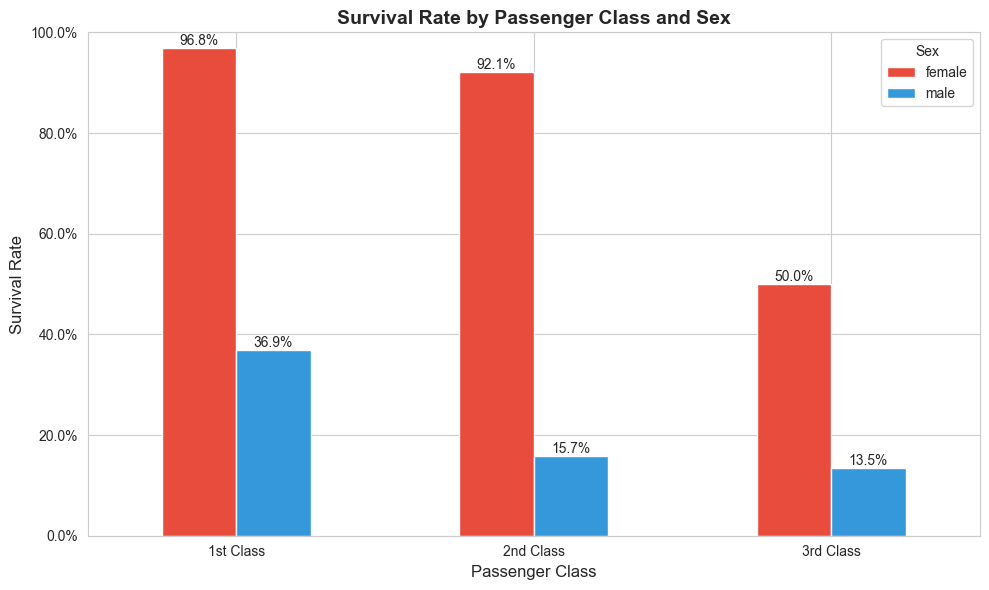

In [10]:
# Figure 1: Survival by Class and Sex
fig, ax = plt.subplots(figsize=(10, 6))

survival_pivot = df_clean.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()
survival_pivot.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'])

ax.set_title('Survival Rate by Passenger Class and Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
ax.legend(title='Sex', loc='upper right')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=1))

# Add percentage labels on bars
for container in ax.containers:
    labels = [f'{value * 100:.1f}%' for value in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='edge', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation:** This plot reveals a clear pattern: women had significantly higher survival rates than men across all passenger classes. First-class passengers also had better survival rates overall, with 1st class women having the highest survival rate (~97%) and 3rd class men having the lowest (~14%). This reflects the "women and children first" evacuation protocol and the preferential access to lifeboats that higher-class passengers received.

### Figure 2: Age Distribution by Survival Status

This visualization compares the age distributions of survivors versus non-survivors.

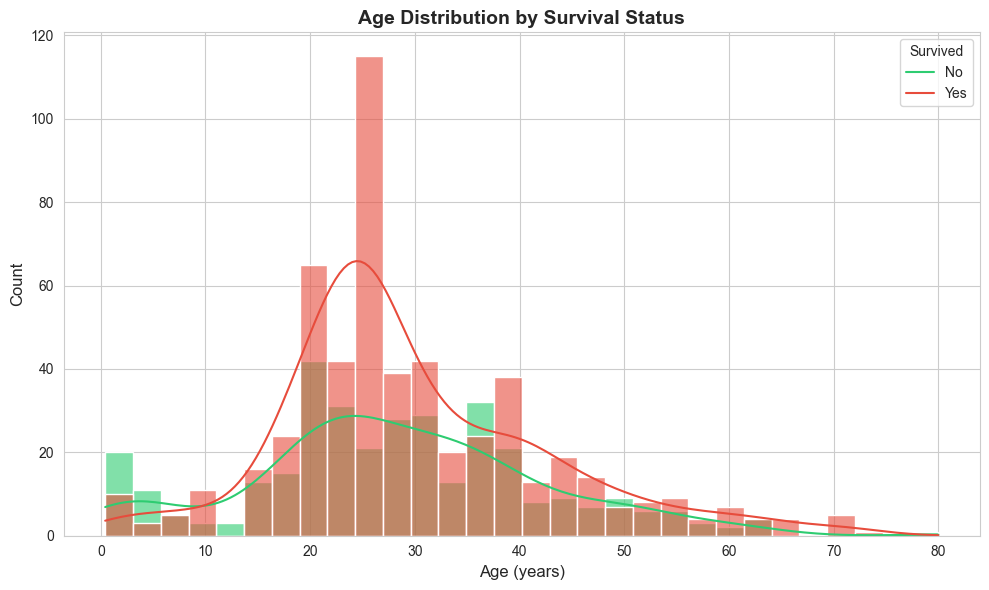

In [11]:
# Figure 2: Age Distribution by Survival
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=df_clean, x='Age', hue='Survived', kde=True, ax=ax,
             palette={0: '#e74c3c', 1: '#2ecc71'}, alpha=0.6, bins=30)

ax.set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

**Interpretation:** The age distribution shows that children (especially those under 10) had higher survival rates compared to adults. The peak of non-survivors is in the 20-30 age range, which corresponds to young adult males who were likely given lower priority during evacuation. The kernel density curves show that survivors tended to be slightly younger on average.

### Figure 3: Correlation Heatmap of Numeric Features

This heatmap shows the correlations between all numeric variables in the dataset.

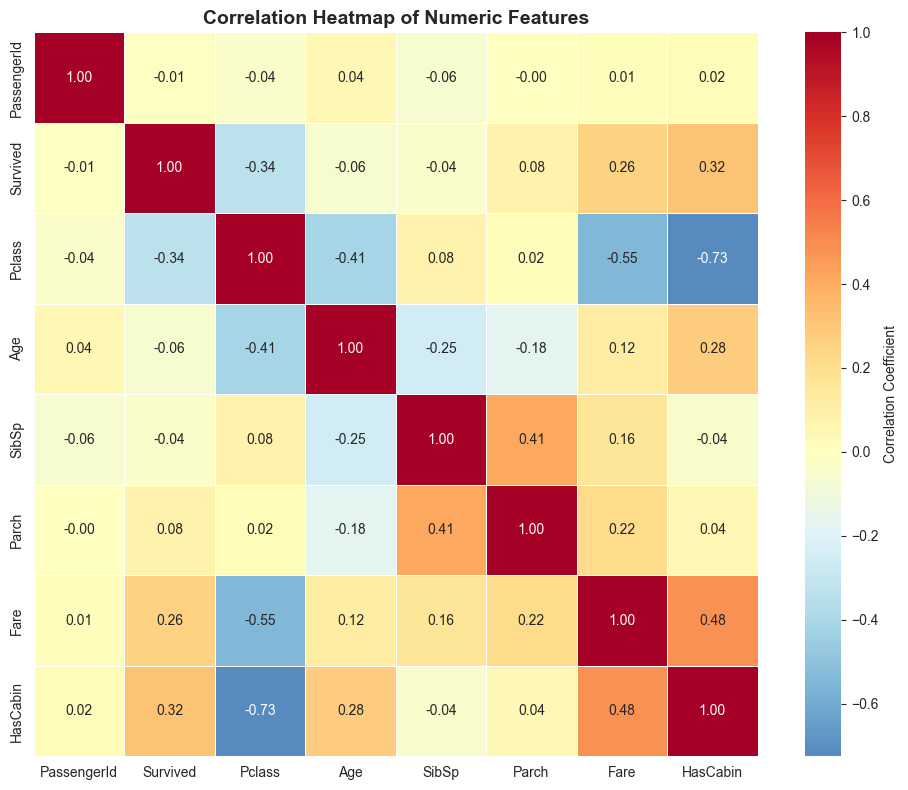

In [12]:
# Figure 3: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Select numeric columns for correlation
numeric_df = df_clean.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', square=True, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:** The heatmap reveals several important relationships:
- **Fare and Pclass** have a strong negative correlation (-0.55), as expected since higher classes cost more
- **Survived and Fare** show a positive correlation (0.26), indicating wealthier passengers had better survival odds
- **Survived and Pclass** are negatively correlated (-0.34), confirming first-class passengers survived at higher rates
- **HasCabin and Survived** are positively correlated (0.32), suggesting cabin assignment (often for higher-paying passengers) was linked to survival
- **SibSp and Parch** are positively correlated (0.41), as families traveling together had both siblings/spouses and parents/children

---
## 6. Summary and Interpretation

### Key Findings

This analysis of the Titanic dataset revealed several important patterns about passenger survival:

1. **Gender was the strongest predictor of survival.** Women had a 74% survival rate compared to only 19% for men. This reflects the "women and children first" evacuation policy that was followed during the disaster.

2. **Passenger class significantly impacted survival chances.** First-class passengers had a 63% survival rate, compared to 47% for second class and only 24% for third class. This disparity likely resulted from cabin locations (first-class cabins were closer to the lifeboats) and potentially preferential treatment during evacuation.

3. **Children had better survival odds.** The age distribution analysis showed that passengers under 10 years old had notably higher survival rates, consistent with the evacuation priority given to children.

4. **Fare and cabin assignment correlated with survival.** Passengers who paid higher fares and had assigned cabins survived at higher rates, which aligns with the class-based survival disparity.

### Limitations and Assumptions

- **Missing Age Data:** Approximately 20% of age values were missing. We imputed these using group medians (by class and sex), which assumes the missing ages follow similar distributions within each group. This assumption may not hold if age data was systematically missing for certain groups.

- **Cabin Data Sparsity:** The Cabin column was 77% missing, making it unusable for detailed analysis. We converted it to a binary feature, but this loses information about cabin location (deck, proximity to lifeboats).

- **Historical Context:** The dataset represents a specific historical event with unique circumstances. Patterns observed may not generalize to other maritime disasters or evacuation scenarios.

### Surprising Observations

- The survival disparity between classes was more pronounced than expected, with third-class male passengers having only a 14% survival rate.
- Having a cabin number recorded (HasCabin) was a stronger predictor of survival than age, suggesting socioeconomic factors played a crucial role beyond the official evacuation protocols.